# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary.

## Answer

From a data science perspective, this task can be defined as a supervised regression problem in which the target variable is the sale price of a used car. The objective is to model the relationship between car price and a set of features, such as vehicle age, mileage, manufacturer, model, condition, fuel type, and transmission (and/or other data present in the dataset), to understand how each feature contributes to the final price.

## The problem to be solved:

As a result of your analysis, you should provide clear recommendations to your client—a used car dealership—as to what consumers value in a used car.

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

In [1]:
import pandas as pd

df = pd.read_csv("data/vehicles.csv")

In [2]:
# Let's see some basic information about the data frame.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  str    
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  str    
 5   model         421603 non-null  str    
 6   condition     252776 non-null  str    
 7   cylinders     249202 non-null  str    
 8   fuel          423867 non-null  str    
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  str    
 11  transmission  424324 non-null  str    
 12  VIN           265838 non-null  str    
 13  drive         296313 non-null  str    
 14  size          120519 non-null  str    
 15  type          334022 non-null  str    
 16  paint_color   296677 non-null  str    
 17  state         426880 non-null  str    
dtypes: float64(2), 

There are quite a lot of non-defined values, so quite a lot of data processing will be needed.

In [3]:
", ".join(list(df.columns))

'id, region, price, year, manufacturer, model, condition, cylinders, fuel, odometer, title_status, transmission, VIN, drive, size, type, paint_color, state'

### Price Distribution (Raw)

Before selecting features, it is useful to inspect the target variable (`price`). The distribution has a large spike near zero and a very long right tail, which is not optimal. Later in data preparation, we will filter implausible prices (e.g. `< 500` and `> 100000`) to stabilize the model.


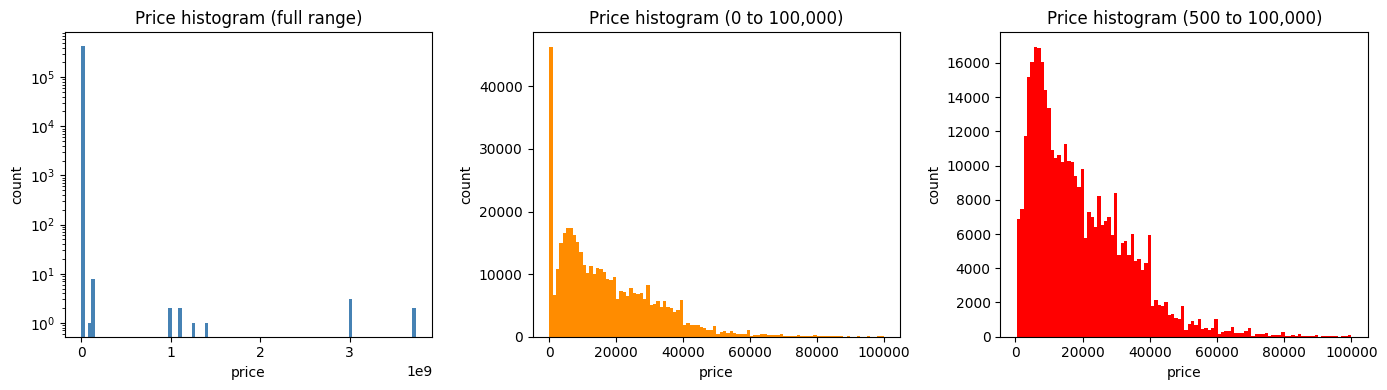

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(df["price"], bins=100, color="steelblue")
axes[0].set_title("Price histogram (full range)")
axes[0].set_xlabel("price")
axes[0].set_ylabel("count")
axes[0].set_yscale("log")

price_main_range = df.loc[df["price"].between(0, 100_000), "price"]
axes[1].hist(price_main_range, bins=100, color="darkorange")
axes[1].set_title("Price histogram (0 to 100,000)")
axes[1].set_xlabel("price")
axes[1].set_ylabel("count")

price_main_range_1 = df.loc[df["price"].between(500, 100_000), "price"]
axes[2].hist(price_main_range_1, bins=100, color="red")
axes[2].set_title("Price histogram (500 to 100,000)")
axes[2].set_xlabel("price")
axes[2].set_ylabel("count")

plt.tight_layout()
plt.show()


 As stated above, from the initial listing, we see that there are quite a lot of non-defined values, so let's create a data frame which will list the types, the percentage of non-numerical values, and the unique values.

Below we will explore the quality of the data and also try to think what factors can influence the price of a car, and also see whether these values are meaningfully represented in the provided data set. 

In [5]:
def display_summary(df):
    summary = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "nan_pct": df.isna().mean().mul(100).round(2),
        "num_unique": [
            df[col].nunique()
            for col in df.columns
        ],
    }, index=df.columns)
    summary = summary.sort_values(["nan_pct"], ascending=[False])
    return summary


summary = display_summary(df)
print(summary)


                dtype  nan_pct  num_unique
size              str    71.77           4
cylinders         str    41.62           8
condition         str    40.79           6
VIN               str    37.73      118246
drive             str    30.59           3
paint_color       str    30.50          12
type              str    21.75          13
manufacturer      str     4.13          42
title_status      str     1.93           6
model             str     1.24       29649
odometer      float64     1.03      104870
fuel              str     0.71           5
transmission      str     0.60           3
year          float64     0.28         114
id              int64     0.00      426880
region            str     0.00         404
price           int64     0.00       15655
state             str     0.00          51


Looking at the data frame with the percentages of NANs, we can see that some columns are really not very informative, because there are just so many missing values. Now we have to decide what to do about those columns. We do not want to unnecessarily deplete the dataset by dropping too many rows, but replacing NaNs with uselss data will not lead to a better understanding.

Looking at the list above, I suppose we can get rid of the columns: the VIN number (probaly if we had access to the database, the VIN number would allow us to know the exact make and model and other parameters)

looking at the drive, we can also delete that column. For the paint colour, we also can't really come up with any kind of generic colour, so I suggest, for the initial investigation, to drop it. The type, for now, we can drop as well and see whether we should really go back to that idea later.

Before doing that, let's have a look at the model and VIN columns.

In [6]:
print(summary.loc[["model"]]["num_unique"].values[0])
print(summary.loc[["VIN"]]["num_unique"].values[0])

29649
118246


Above we saw that there are 265000 VIN nubers but only 118246 unique values which indicates a serious problem with the data because a VIN number is supposed to be a unique identifier for a car. This means that there are many repeated entries in the dataset, which can lead to overfitting and unreliable models. Let's have a closer look at teh VIN number.

In [7]:
# Check for repeated VIN numbers before dropping the column

df_original = pd.read_csv("data/vehicles.csv")
vin_counts = df_original["VIN"].value_counts()
repeated_vins = vin_counts[vin_counts > 1].head(10)

if len(repeated_vins) > 0:
    print(f"Found {len(vin_counts[vin_counts > 1])} unique VINs that are repeated")
    print("\nTop 10 repeated VINs:")
    print(repeated_vins)
else:
    print("No repeated VINs found")


Found 40280 unique VINs that are repeated

Top 10 repeated VINs:
VIN
1FMJU1JT1HEA52352    261
3C6JR6DT3KG560649    235
1FTER1EH1LLA36301    231
5TFTX4CN3EX042751    227
1GCHTCE37G1186784    214
1GTN1TEH5EZ273019    207
3VWF17AT1FM655022    199
JN1AZ4EH8KM420880    198
1FTMF1CP3GKD62143    195
1GTR1WE07DZ143724    194
Name: count, dtype: int64


So let's have a lok at one of the repeated VIN numbers and see what is the data for those entries.

In [8]:
df[df["VIN"] == '1FMJU1JT1HEA52352']

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
76,7311818189,auburn,29590,2017.0,ford,expedition xlt sport,good,6 cylinders,gas,70760.0,clean,other,1FMJU1JT1HEA52352,4wd,NaN,SUV,blue,al
707,7311865995,birmingham,29590,2017.0,ford,expedition xlt sport,good,6 cylinders,gas,70760.0,clean,other,1FMJU1JT1HEA52352,4wd,NaN,SUV,blue,al
1935,7311801032,dothan,29590,2017.0,ford,expedition xlt sport,good,6 cylinders,gas,70760.0,clean,other,1FMJU1JT1HEA52352,4wd,NaN,SUV,blue,al
2201,7311915565,florence / muscle shoals,29590,2017.0,ford,expedition xlt sport,good,6 cylinders,gas,70760.0,clean,other,1FMJU1JT1HEA52352,4wd,NaN,SUV,blue,al
2377,7311823034,gadsden-anniston,29590,2017.0,ford,expedition xlt sport,good,6 cylinders,gas,70760.0,clean,other,1FMJU1JT1HEA52352,4wd,NaN,SUV,blue,al
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
420611,7311842926,madison,29590,2017.0,ford,expedition xlt sport,good,6 cylinders,gas,70760.0,clean,other,1FMJU1JT1HEA52352,4wd,NaN,SUV,blue,wi
423786,7311784162,milwaukee,29590,2017.0,ford,expedition xlt sport,good,6 cylinders,gas,70760.0,clean,other,1FMJU1JT1HEA52352,4wd,NaN,SUV,blue,wi
425368,7311832579,sheboygan,29590,2017.0,ford,expedition xlt sport,good,6 cylinders,gas,70760.0,clean,other,1FMJU1JT1HEA52352,4wd,NaN,SUV,blue,wi
425834,7311967545,wausau,29590,2017.0,ford,expedition xlt sport,good,6 cylinders,gas,70760.0,clean,other,1FMJU1JT1HEA52352,4wd,NaN,SUV,blue,wi


From the above list it is obvious that the same listings are repeated for many locations with the same VIN and other data. So I will drop the region column as useless information as well as the id and then eliminate duplicates.

The `model` column has very high cardinality (around 29,000 unique values), which makes a simple one-hot baseline harder to fit and interpret. However, high cardinality does **not** mean the field is useless. For now, we will drop `model` in the baseline and focus on cleaner categorical features, but it could be revisited later with grouping/normalization of rare values.


We see that there is a number of categorical variables, and some of them have quite a few unique features. Let's see what is the number of represented entries in the database for each of the categories

In [9]:
# Display the number of entries for each category in the 'manufacturer' column
manufacturer_counts = df["manufacturer"].value_counts()
print(manufacturer_counts)

manufacturer
ford               70985
chevrolet          55064
toyota             34202
honda              21269
nissan             19067
jeep               19014
ram                18342
gmc                16785
bmw                14699
dodge              13707
mercedes-benz      11817
hyundai            10338
subaru              9495
volkswagen          9345
kia                 8457
lexus               8200
audi                7573
cadillac            6953
chrysler            6031
acura               5978
buick               5501
mazda               5427
infiniti            4802
lincoln             4220
volvo               3374
mitsubishi          3292
mini                2376
pontiac             2288
rover               2113
jaguar              1946
porsche             1384
mercury             1184
saturn              1090
alfa-romeo           897
tesla                868
fiat                 792
harley-davidson      153
ferrari               95
datsun                63
aston-martin

In [10]:
# Display the number of entries for each category in the 'size' column
size_counts = df["size"].value_counts()
print(size_counts)

size
full-size      63465
mid-size       34476
compact        19384
sub-compact     3194
Name: count, dtype: int64


In [11]:
# Display the number of entries for each category in the 'drive' column
drive_counts = df["drive"].value_counts()
print(drive_counts)

drive
4wd    131904
fwd    105517
rwd     58892
Name: count, dtype: int64


In [12]:
# Display the number of entries for each category in the 'type' column
type_counts = df["type"].value_counts()
print(type_counts)

type
sedan          87056
SUV            77284
pickup         43510
truck          35279
other          22110
coupe          19204
hatchback      16598
wagon          10751
van             8548
convertible     7731
mini-van        4825
offroad          609
bus              517
Name: count, dtype: int64


In [13]:
# Display the number of entries for each category in the 'title_status' column
title_status_counts = df["title_status"].value_counts()
print(title_status_counts)

title_status
clean         405117
rebuilt         7219
salvage         3868
lien            1422
missing          814
parts only       198
Name: count, dtype: int64


In [14]:
# Display the number of entries for each category in the 'transmission' column
transmission_counts = df["transmission"].value_counts()
print(transmission_counts)

transmission
automatic    336524
other         62682
manual        25118
Name: count, dtype: int64


In [15]:
# Display the number of entries for each category in the 'fuel' column
fuel_counts = df["fuel"].value_counts()
print(fuel_counts)

fuel
gas         356209
other        30728
diesel       30062
hybrid        5170
electric      1698
Name: count, dtype: int64


## Summary fo findings and general considerations for data preparation

The question of the problem that we are tackling is to define the factors that influence the price of a car. Before we build a model, we need to select the features that we want to be included, and also we want to see what data should be selected.

Looking at the data above, we should first of all delete the state column and then eliminate all duplicates, which will leave just unique VIN numbers left.


If we want to see the price of a car, I think we should also select either the manufacturer and the car type, because it wouldn't be sensible to compare trucks with sedans to include them in one model. We will build a function that will return the desired rows.

The original list of features is:

'id, region, price, year, manufacturer, model, condition, cylinders, fuel, odometer, title_status, transmission, VIN, drive, size, type, paint_color, state'

So after elimination the id, region, VIN, state columns and model, we will have the following features left:

'price, year, manufacturer, condition, cylinders, fuel, odometer, title_status, transmission, drive, size, type, paint_color'

I am also deciding to leave only clean status and drop that column, because the other statuses are not very well represented in the dataset, and also they are not very informative. For example, if a car is listed as "salvage", it is probably not worth much, but there are only 1000 such cars in the dataset, which is not enough to build a good model. So we will drop all cars that are not listed as "clean" and then drop that column.

We will restrict the price from 500 to 30000, the year from 2000 to 2022, and the odometer from 0 to 500000, which will eliminate outliers and stabilize the model.

30000 for max price was chosen arbitrarily, but it seems that there are not many cars above that price in the dataset, and also it is a reasonable price for a used car.

We will define a function that will return the desired rows based on the **manufacturer** and **type** of the car. It is clear that the make influences the price of the car, and also the type of the car (e.g. truck vs sedan) is also a very important factor that influences the price. So it would be better to build separate models for different types of cars, and then see what are the most important factors for each type of car.

So we will be left with the follwoing features:

'price, year, condition, cylinders, fuel, odometer, title_status, transmission, drive, size, paint_color'3

At this stage we will drop NaN's. Instead of year we will use the age.

As the target we will use the log of the price, because the price distribution is right-skewed and also because the price of a car is determined by multiplicative factors rather than additive (e.g. a car with twice the mileage is not necessarily worth exactly half the price, but it could be worth 30% less, which is a multiplicative relationship that can be captured by a log transformation).

Among the features we have numerical features: odometer and age.
We also have categorical features: condition, cylinders, fuel, title_status, transmission, drive, size, paint_color.

We can try to one-hot encode the categorical features, but for condition, cylinders and size we can also try ordinal encoding, because they have a natural ordering (e.g. excellent > good > fair). We can compare the performance of both approaches.

### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`.


In [16]:
df_raw = pd.read_csv("data/vehicles.csv")

df_raw.drop(columns=["id", "region", "state"], inplace=True)
df_raw.drop_duplicates(inplace=True)
df_raw.drop(columns=["VIN", "model"], inplace=True)
# We will restrict the price from 500 to 30000, the year from 2000 to 2022, and the odometer from 0 to 500000, which will eliminate outliers and stabilize the model.

df_raw.dropna(inplace=True)
df_raw = df_raw[df_raw["price"].between(500, 30_000)]
df_raw = df_raw[df_raw["odometer"].between(0, 500_000)]
df_raw = df_raw[df_raw["year"].between(2000, 2022)]
df_raw["age"] = 2023 - df_raw["year"]
df_raw.drop(columns=["year"], inplace=True)
df_raw = df_raw[df_raw["title_status"] == "clean"]
df_raw.drop(columns=["title_status"], inplace=True)

display(df_raw.info())

display_summary(df_raw)

<class 'pandas.DataFrame'>
Index: 44296 entries, 31 to 426760
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   price         44296 non-null  int64  
 1   manufacturer  44296 non-null  str    
 2   condition     44296 non-null  str    
 3   cylinders     44296 non-null  str    
 4   fuel          44296 non-null  str    
 5   odometer      44296 non-null  float64
 6   transmission  44296 non-null  str    
 7   drive         44296 non-null  str    
 8   size          44296 non-null  str    
 9   type          44296 non-null  str    
 10  paint_color   44296 non-null  str    
 11  age           44296 non-null  float64
dtypes: float64(2), int64(1), str(9)
memory usage: 4.4 MB


None

,dtype,nan_pct,num_unique
price,int64,0.0,2893
manufacturer,str,0.0,38
condition,str,0.0,6
cylinders,str,0.0,8
fuel,str,0.0,5
odometer,float64,0.0,21565
transmission,str,0.0,3
drive,str,0.0,3
size,str,0.0,4
type,str,0.0,13


In [17]:
def select_data(df, manufacturer="ford", car_type="sedan", show_msg=True):
    """
    selects the data for the given manufacturer and car type. If the manufacturer or car type is not found in the dataset, it raises a ValueError with an appropriate message.
    :param df: dataframe to select from
    :param manufacturer:
    :param car_type:
    :return: restricted dataframe
    """
    if manufacturer not in df["manufacturer"].unique():
        if show_msg:
            print(f"Manufacturer '{manufacturer}' not found in the dataset.")
        raise ValueError(f"Manufacturer '{manufacturer}' not found in the dataset.")
    df = df[df["manufacturer"] == manufacturer].copy()
    df.drop(columns=["manufacturer"], inplace=True)
    if car_type not in df["type"].unique():
        if show_msg:
            print(f"Type '{car_type}' not found in the dataset.")
        raise ValueError(f"Type '{car_type}' not found in the dataset.")
    df = df[df["type"] == car_type]
    df.drop(columns=["type"], inplace=True)
    return df


In [18]:
# Let's check how this works for some manufacturers and car types. We will select sedans for Ford and Toyota, and trucks and sedans for Chevrolet, because these are the most represented categories in the dataset.

df_ford_sedan = select_data(df_raw, manufacturer="ford", car_type="sedan")
print(df_ford_sedan.info())
df_toyota_sedan = select_data(df_raw, manufacturer="toyota", car_type="sedan")
print(df_toyota_sedan.info())
df_chevrolet_truck = select_data(df_raw, manufacturer="chevrolet", car_type="truck")
print(df_chevrolet_truck.info())
df_chevrolet_sedan = select_data(df_raw, manufacturer="chevrolet", car_type="sedan")
print(df_chevrolet_sedan.info())

<class 'pandas.DataFrame'>
Index: 1350 entries, 1789 to 426658
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   price         1350 non-null   int64  
 1   condition     1350 non-null   str    
 2   cylinders     1350 non-null   str    
 3   fuel          1350 non-null   str    
 4   odometer      1350 non-null   float64
 5   transmission  1350 non-null   str    
 6   drive         1350 non-null   str    
 7   size          1350 non-null   str    
 8   paint_color   1350 non-null   str    
 9   age           1350 non-null   float64
dtypes: float64(2), int64(1), str(7)
memory usage: 116.0 KB
None
<class 'pandas.DataFrame'>
Index: 1610 entries, 215 to 426720
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   price         1610 non-null   int64  
 1   condition     1610 non-null   str    
 2   cylinders     1610 non-null   str    
 3   fuel    

In [19]:
def encode_one_hot_dataframe(df):
    """
    One-hot encode all categorical columns.
    :param df:
    :return:
    """
    categorical_cols = df.select_dtypes(include=["str"]).columns
    return pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype=int)


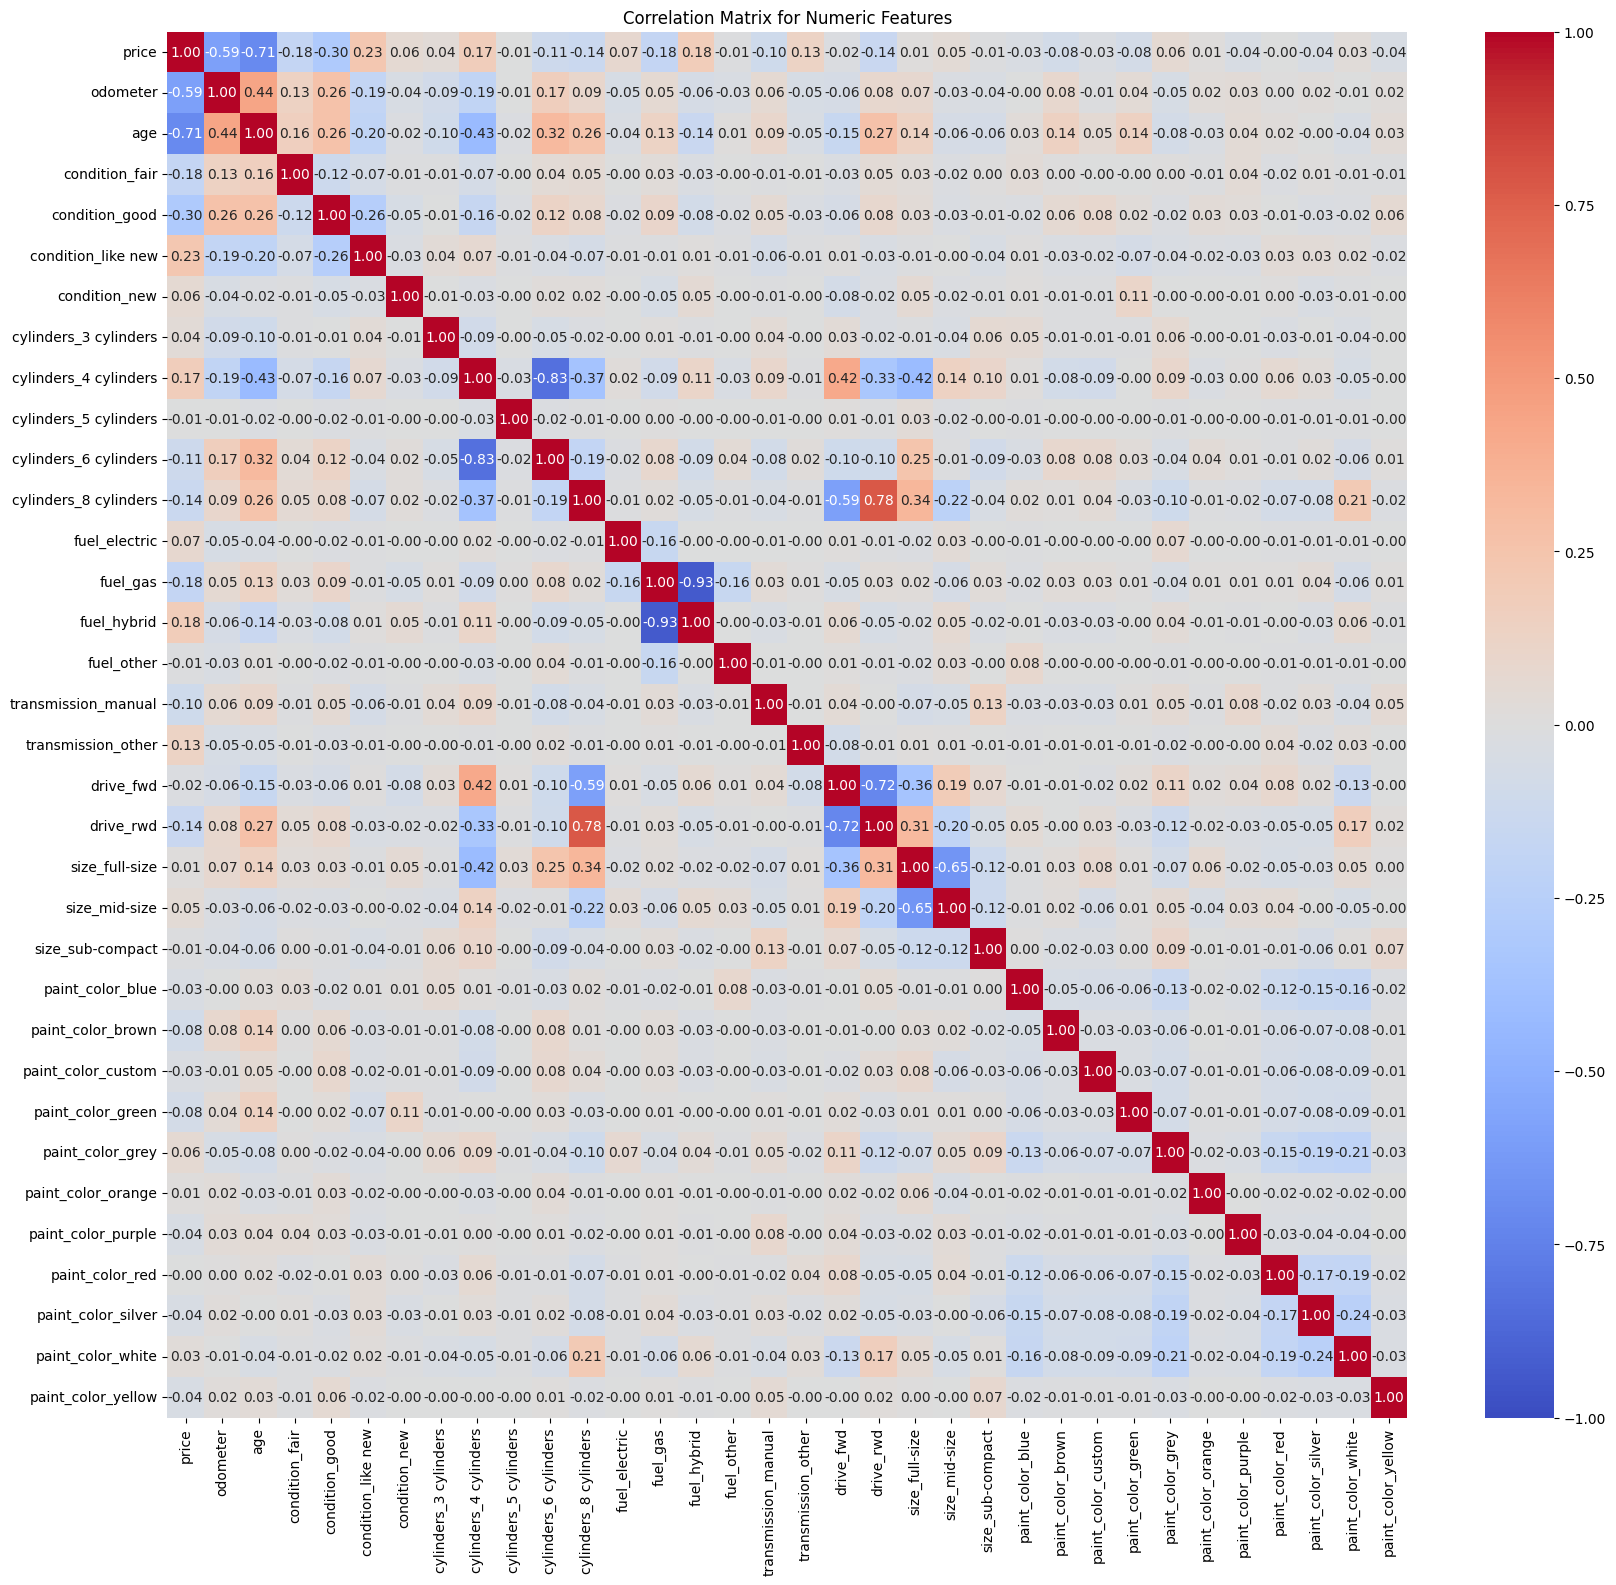

In [20]:
#Let's check the correlation mattrix as an example for the Ford sedans, which the most represented category in the dataset. We will one-hot encode the categorical features and then check the correlation matrix for numeric features.

df_fs = encode_one_hot_dataframe(df_ford_sedan)
numeric_cols = df_fs.select_dtypes(include=["number"]).columns
# Let's check the correlation matrix for numeric features

import seaborn as sns

plt.figure(figsize=(20, 18))
sns.heatmap(df_fs[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix for Numeric Features")
plt.show()


### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

Let's start with LASSO regression to see whether features can be eliminated. We can try a few polynomial degrees to see whether that improves the model.

The target variable is **log(price)** — this accounts for the right-skewed price distribution and the fact that car attributes combine multiplicatively rather than additively

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import TransformedTargetRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, make_scorer
from sklearn.model_selection import GridSearchCV, train_test_split

from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline

def analyse_manufacturer_type(df_raw, manufacturer, car_type):
    df = select_data(df_raw, manufacturer=manufacturer, car_type=car_type)
    df = encode_one_hot_dataframe(df)

    X, y = df.drop(columns=["price"]), df["price"]

    # Create the feature transformation pipeline
    feature_pipeline_1 = Pipeline([
        ('polyfeatures', PolynomialFeatures(include_bias=True)),
        ('scaler', StandardScaler()),
        ('lasso', Lasso(random_state=42, max_iter=100000))
    ])

    # Wrap with TransformedTargetRegressor to include log transformation in the pipeline
    car_pipe_1 = TransformedTargetRegressor(
        regressor=feature_pipeline_1,
        func=np.log,  # Transform y using log
        inverse_func=np.exp  # Transform predictions back using exp
    )
    parameters_to_try = {
        'regressor__polyfeatures__degree': [1, 2],
        'regressor__lasso__alpha': [0.001, 0.002, 0.003, 0.005, 0.01]
    }
    model_finder = GridSearchCV(estimator=car_pipe_1,
                                param_grid=parameters_to_try,
                                scoring="neg_mean_squared_error",
                                n_jobs=12,
                                cv=4)
    model_finder.fit(X, y)
    model_finder.cv_results_
    print("Best parameters found: ", model_finder.best_params_)
    print("Best CV MSE: ", (-model_finder.best_score_) ** 0.5)

    selected_model = model_finder.best_estimator_
    y_pred = selected_model.predict(X)
    final_mse = mean_squared_error(y, y_pred)
    print(f"Final MSE on the entire dataset: {final_mse:,.2f}")
    print(f"Final RMSE on the entire dataset: ${np.sqrt(final_mse):,.2f}")
    # r^2 score on the entire dataset
    final_r2 = selected_model.score(X, y)
    print(f"Final R^2 Score on the entire dataset: {final_r2:.4f}")

    feature_names = selected_model.regressor_.named_steps['polyfeatures'].get_feature_names_out()
    lasso_coefs = selected_model.regressor_.named_steps['lasso'].coef_
    lasso_df = pd.DataFrame({'feature': feature_names, 'coef': lasso_coefs})
    print(lasso_df.loc[lasso_df['coef'] != 0].sort_values(by='coef', key=abs, ascending=False).head(20))
    plt.figure(figsize=(5, 5))
    sns.scatterplot(x=y, y=y_pred, alpha=0.5)
    plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
    plt.xlabel("Actual Price")
    plt.ylabel("Predicted Price")
    plt.title("Actual vs Predicted Price")
    plt.show()

    # -------- Permutation importance on a hold-out set  --------
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )
    selected_model.fit(X_train, y_train)

    # RMSE scorer (scikit expects "higher is better", so we return negative RMSE)
    def neg_rmse(y_true, y_pred):
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        return -rmse

    rmse_scorer = make_scorer(neg_rmse, greater_is_better=True)

    perm = permutation_importance(
        selected_model,
        X_test,
        y_test,
        scoring=rmse_scorer,  # importance measured by drop in (negative) RMSE score
        n_repeats=10,
        random_state=42,
        n_jobs=12
    )

    # Feature names: after one-hot, X already has final column names
    perm_df = pd.DataFrame({
        "feature": X_test.columns,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std,
    }).sort_values("importance_mean", ascending=False)

    print(perm_df.head(20))


Best parameters found:  {'regressor__lasso__alpha': 0.003, 'regressor__polyfeatures__degree': 1}
Best CV MSE:  2379.6146658433568
Final MSE on the entire dataset: 5,344,615.57
Final RMSE on the entire dataset: $2,311.84
Final R^2 Score on the entire dataset: 0.6951
                  feature      coef
2                     age -0.362850
1                odometer -0.182076
3          condition_fair -0.091634
18              drive_fwd -0.058927
4          condition_good -0.051444
8   cylinders_4 cylinders -0.034994
20         size_full-size  0.034328
13               fuel_gas -0.033569
22       size_sub-compact -0.025758
31     paint_color_silver -0.023442
19              drive_rwd -0.022440
21          size_mid-size  0.022150
10  cylinders_6 cylinders  0.018312
7   cylinders_3 cylinders -0.018070
32      paint_color_white -0.013009
15             fuel_other -0.010670
17     transmission_other  0.009595
9   cylinders_5 cylinders -0.007200
16    transmission_manual -0.006429
5      conditi

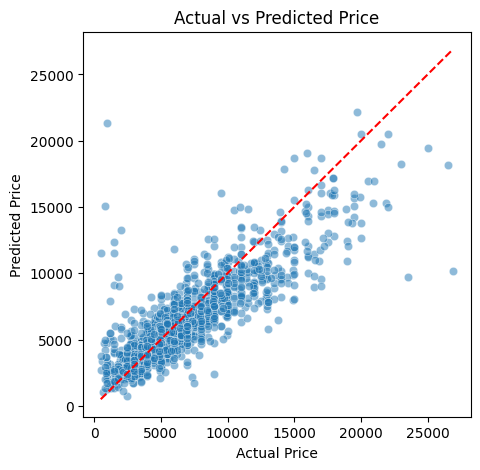

                  feature  importance_mean  importance_std
1                     age      2047.962712       65.230590
0                odometer       921.332733       92.942843
3          condition_good        80.079064       17.497006
2          condition_fair        76.340524       23.329950
17              drive_fwd        60.134980       34.773959
9   cylinders_6 cylinders        43.940174       23.207175
13            fuel_hybrid        38.761281       10.323084
30     paint_color_silver        24.593539        7.844400
21       size_sub-compact        16.042188       17.554228
6   cylinders_3 cylinders        12.900183       15.740569
18              drive_rwd         8.199442        3.743960
19         size_full-size         6.577618        4.352522
15    transmission_manual         2.825175        2.090059
24     paint_color_custom         0.000000        0.000000
22       paint_color_blue         0.000000        0.000000
20          size_mid-size         0.000000        0.0000

In [22]:
analyse_manufacturer_type(df_raw, manufacturer="ford", car_type="sedan")

In [23]:



def _df_to_pretty_text(df: pd.DataFrame, max_rows: int = 15, floatfmt: str = "{:,.4g}") -> str:
    """
    Convert a small DataFrame to a compact monospaced text block for matplotlib axes.
    """
    df_show = df.head(max_rows).copy()

    for col in df_show.columns:
        if pd.api.types.is_numeric_dtype(df_show[col]):
            df_show[col] = df_show[col].map(lambda x: floatfmt.format(x) if pd.notna(x) else "")

    return df_show.to_string(index=False)


def _dict_to_pretty_text(d: dict, floatfmt: str = "{:,.4g}") -> str:
    """
    Convert a dict to aligned key:value lines for matplotlib axes.
    """
    d2 = {}
    for k, v in d.items():
        if isinstance(v, (float, np.floating, int, np.integer)):
            d2[k] = floatfmt.format(v)
        else:
            d2[k] = str(v)

    width = max(len(str(k)) for k in d2.keys())
    return "\n".join([f"{str(k):<{width}} : {v}" for k, v in d2.items()])


def analyse_manufacturer_type(
      df_raw: pd.DataFrame,
      manufacturer: str,
      car_type: str,
      top_n: int = 15,
      n_repeats: int = 10,
      test_size: float = 0.3,
      random_state: int = 42,
      n_jobs: int = 12,
      show_perm_bar: bool = True,
      show_report:bool = True
):
    """
    Runs a Lasso + PolynomialFeatures model with log-target transform, performs CV grid search,
    evaluates on a hold-out set, and displays a compact dashboard (summary + tables + scatter).
    """
    # --- Prepare data ---
    df = select_data(df_raw, manufacturer=manufacturer, car_type=car_type, show_msg=show_report)
    df = encode_one_hot_dataframe(df)

    if "price" not in df.columns:
        raise ValueError("Expected a 'price' column in the encoded dataframe.")

    X, y = df.drop(columns=["price"]), df["price"]

    # --- Pipeline + target transform ---
    feature_pipeline = Pipeline([
        ("polyfeatures", PolynomialFeatures(include_bias=True)),
        ("scaler", StandardScaler()),
        ("lasso", Lasso(random_state=random_state, max_iter=100000)),
    ])

    model = TransformedTargetRegressor(
        regressor=feature_pipeline,
        func=np.log,
        inverse_func=np.exp,
    )

    # --- CV search ---
    param_grid = {
        "regressor__polyfeatures__degree": [1],
        "regressor__lasso__alpha": [0.001, 0.002, 0.003, 0.005, 0.01],
    }

    search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        scoring="neg_mean_squared_error",
        cv=4,
        n_jobs=n_jobs,
    )
    search.fit(X, y)
    best_model = search.best_estimator_

    # --- Hold-out evaluation ---
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )
    best_model.fit(X_train, y_train)

    y_pred_train = best_model.predict(X_train)
    y_pred_test = best_model.predict(X_test)

    train_rmse = float(np.sqrt(mean_squared_error(y_train, y_pred_train)))
    test_rmse = float(np.sqrt(mean_squared_error(y_test, y_pred_test)))
    test_r2 = float(best_model.score(X_test, y_test))
    cv_rmse = float(np.sqrt(-search.best_score_))

    # --- Lasso coefficients (polynomial terms) ---
    poly = best_model.regressor_.named_steps["polyfeatures"]
    lasso = best_model.regressor_.named_steps["lasso"]

    coef_df = pd.DataFrame({
        "term": poly.get_feature_names_out(X.columns),
        "coef": lasso.coef_,
    })
    coef_df = coef_df.loc[coef_df["coef"] != 0].copy()
    coef_df["abs_coef"] = coef_df["coef"].abs()
    coef_top = (
        coef_df.sort_values("abs_coef", ascending=False)
        .head(top_n)[["term", "coef"]]
        .reset_index(drop=True)
    )

    # --- Permutation importance (original input features) ---
    def neg_rmse(y_true, y_pred):
        return -float(np.sqrt(mean_squared_error(y_true, y_pred)))

    rmse_scorer = make_scorer(neg_rmse, greater_is_better=True)

    perm = permutation_importance(
        best_model,
        X_test,
        y_test,
        scoring=rmse_scorer,
        n_repeats=n_repeats,
        random_state=random_state,
        n_jobs=n_jobs,
    )

    perm_df = pd.DataFrame({
        "feature": X.columns,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std,
    }).sort_values("importance_mean", ascending=False)

    perm_top = perm_df.head(top_n).reset_index(drop=True)

    # --- Summary (compact) ---
    summary = pd.DataFrame([{
        "manufacturer": manufacturer,
        "car_type": car_type,
        "rows": int(len(df)),
        "features": int(X.shape[1]),
        "best_degree": int(search.best_params_["regressor__polyfeatures__degree"]),
        "best_alpha": float(search.best_params_["regressor__lasso__alpha"]),
        "cv_RMSE": cv_rmse,
        "train_RMSE": train_rmse,
        "test_RMSE": test_rmse,
        "test_R2": test_r2,
        "nonzero_lasso_terms": int((lasso.coef_ != 0).sum()),
    }])
    if show_report:
        # Display summary as a normal compact dataframe (no .style, no jinja2 needed)
        summary_fmt = summary.copy()
        summary_fmt["cv_RMSE"] = summary_fmt["cv_RMSE"].map("{:,.2f}".format)
        summary_fmt["train_RMSE"] = summary_fmt["train_RMSE"].map("{:,.2f}".format)
        summary_fmt["test_RMSE"] = summary_fmt["test_RMSE"].map("{:,.2f}".format)
        summary_fmt["test_R2"] = summary_fmt["test_R2"].map("{:.4f}".format)
        display(summary_fmt)

        # -------- Improved compact display: monospaced "tables" + smaller scatter --------
        summary_row = summary.iloc[0].to_dict()
        summary_compact = {
            "manufacturer": summary_row["manufacturer"],
            "car_type": summary_row["car_type"],
            "rows": summary_row["rows"],
            "features": summary_row["features"],
            "best_degree": summary_row["best_degree"],
            "best_alpha": summary_row["best_alpha"],
            "cv_RMSE": summary_row["cv_RMSE"],
            "test_RMSE": summary_row["test_RMSE"],
            "test_R2": summary_row["test_R2"],
            "nonzero_terms": summary_row["nonzero_lasso_terms"],
        }

        summary_text = _dict_to_pretty_text(summary_compact, floatfmt="{:,.4g}")
        coef_text = _df_to_pretty_text(coef_top, max_rows=top_n, floatfmt="{:+.4g}")
        perm_text = _df_to_pretty_text(
            perm_top.rename(columns={"importance_mean": "mean", "importance_std": "std"}),
            max_rows=top_n,
            floatfmt="{:,.4g}",
        )

        plt.close("all")
        fig = plt.figure(figsize=(6, 5), constrained_layout=True)
        gs = fig.add_gridspec(
            nrows=2, ncols=2,
            width_ratios=[1.1, 1.4],
            height_ratios=[1.0, 1.2]
        )

        # Summary panel (top-left)
        ax_sum = fig.add_subplot(gs[0, 0])
        ax_sum.axis("off")
        ax_sum.set_title("Model summary", fontsize=12, pad=8)
        ax_sum.text(
            0.0, 1.0, summary_text,
            va="top", ha="left",
            family="monospace",
            fontsize=11
        )

        # Scatter panel (top-right) - smaller & cleaner
        ax_sc = fig.add_subplot(gs[0, 1])
        sns.scatterplot(x=y_test, y=y_pred_test, alpha=0.35, ax=ax_sc, s=18)
        min_v = float(min(y_test.min(), y_pred_test.min()))
        max_v = float(max(y_test.max(), y_pred_test.max()))
        ax_sc.plot([min_v, max_v], [min_v, max_v], linestyle="--")
        ax_sc.set_title("Actual vs Predicted (test)", fontsize=12)
        ax_sc.set_xlabel("Actual price", fontsize=10)
        ax_sc.set_ylabel("Predicted price", fontsize=10)
        ax_sc.tick_params(labelsize=9)

        # Lasso terms (bottom-left)
        ax_lasso = fig.add_subplot(gs[1, 0])
        ax_lasso.axis("off")
        ax_lasso.set_title(f"Top {top_n} Lasso terms (non-zero)", fontsize=12, pad=8)
        ax_lasso.text(
            0.0, 1.0, coef_text,
            va="top", ha="left",
            family="monospace",
            fontsize=10
        )

        # Permutation importances (bottom-right)
        ax_perm = fig.add_subplot(gs[1, 1])
        ax_perm.axis("off")
        ax_perm.set_title(f"Top {top_n} permutation importances (test)", fontsize=12, pad=8)
        ax_perm.text(
            0.0, 1.0, perm_text,
            va="top", ha="left",
            family="monospace",
            fontsize=10
        )


        plt.show()

        # Optional: compact bar plot of permutation importance (visual ranking)
        if show_perm_bar:
            plt.figure(figsize=(5, 3))
            sns.barplot(
                data=perm_top.iloc[::-1],
                x="importance_mean",
                y="feature",
                orient="h",
                errorbar=None,
            )
            plt.xlabel("Permutation importance (Δ score)")
            plt.ylabel("")
            plt.title("Top permutation importances (test set)")
            plt.tight_layout()
            plt.show()

    return {
        "summary": summary,
        "coef_top": coef_top,
        "perm_top": perm_top,
        "best_model": best_model,
        "search": search,
    }


# Summary

I have decided to use only the Lasso model because it zeroes the coefficients that matter least for the outcome.

After trying to find best paraemters a few times, I decided to just leave the first order polynomial (linear relationshop) because higher orders gave some illogical features.

### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

,manufacturer,car_type,rows,features,best_degree,best_alpha,cv_RMSE,train_RMSE,test_RMSE,test_R2,nonzero_lasso_terms
0,ford,sedan,1350,33,1,0.003,"2,379.61","2,374.09","2,322.90",0.7168,25


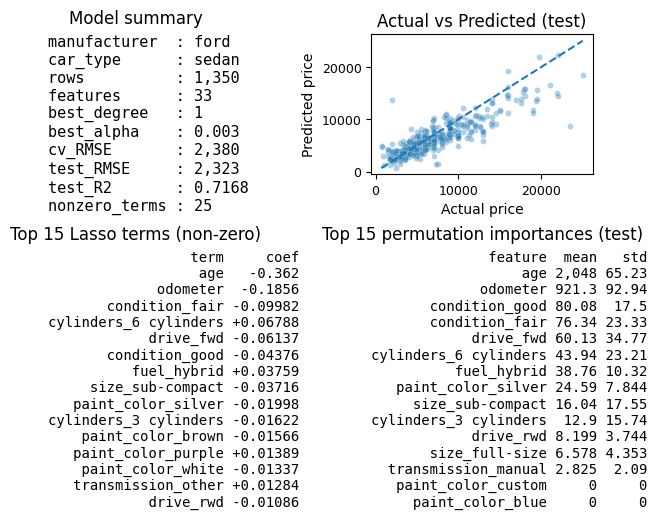

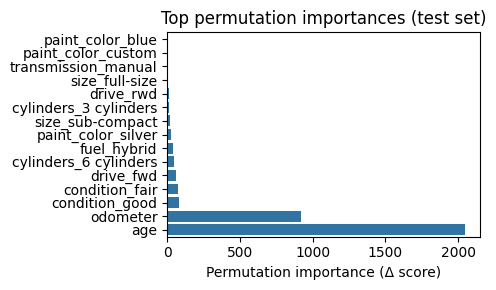

In [24]:
results_ford_sedan = analyse_manufacturer_type(df_raw, manufacturer="ford", car_type="sedan")

,manufacturer,car_type,rows,features,best_degree,best_alpha,cv_RMSE,train_RMSE,test_RMSE,test_R2,nonzero_lasso_terms
0,toyota,sedan,1610,33,1,0.001,"2,429.20","2,361.25","2,221.50",0.7851,29


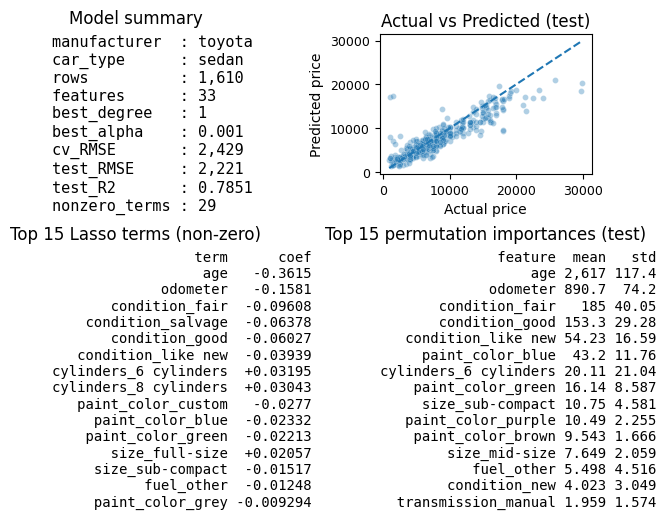

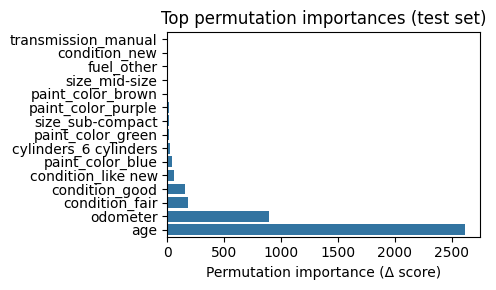

In [25]:
results_toyota_sedan = analyse_manufacturer_type(df_raw, manufacturer="toyota", car_type="sedan")

,manufacturer,car_type,rows,features,best_degree,best_alpha,cv_RMSE,train_RMSE,test_RMSE,test_R2,nonzero_lasso_terms
0,chevrolet,truck,1229,33,1,0.005,"4,364.38","4,143.98","4,430.68",0.6630,24


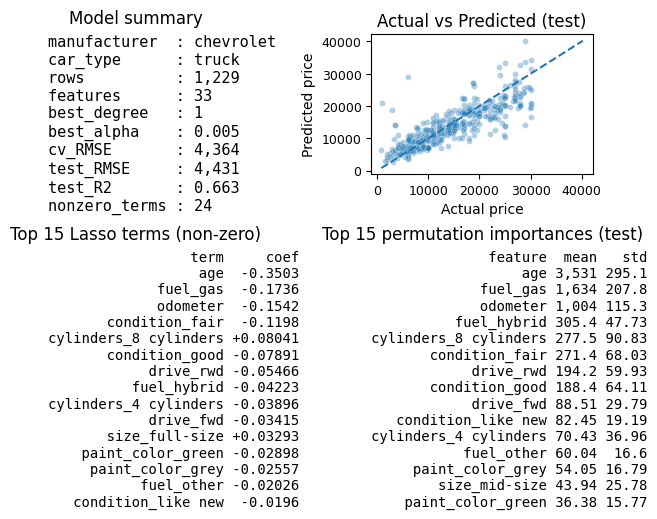

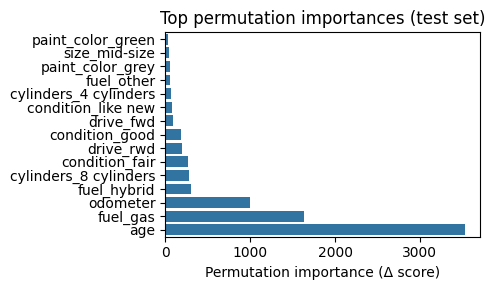

In [26]:
results_chevrolet_truck = analyse_manufacturer_type(df_raw, manufacturer="chevrolet", car_type="truck")

,manufacturer,car_type,rows,features,best_degree,best_alpha,cv_RMSE,train_RMSE,test_RMSE,test_R2,nonzero_lasso_terms
0,chevrolet,sedan,1444,34,1,0.005,"2,808.51","2,616.68","2,821.88",0.5448,23


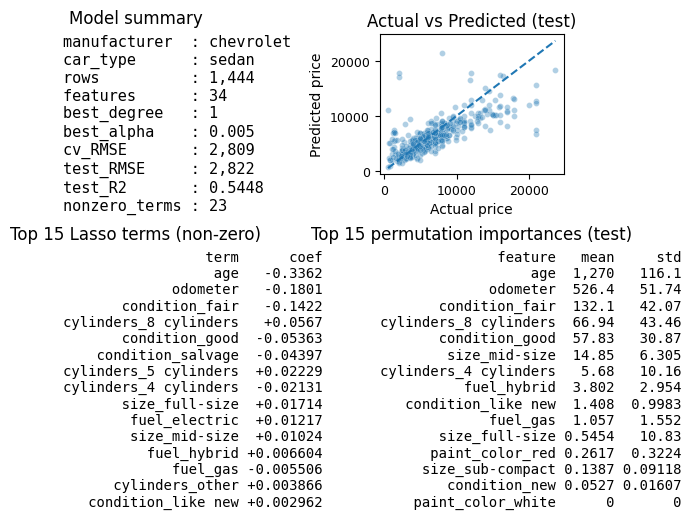

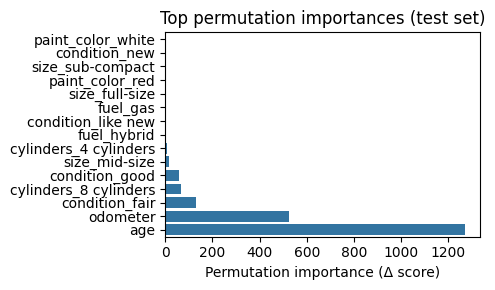

In [27]:
results_toyota_sedan = analyse_manufacturer_type(df_raw, manufacturer="chevrolet", car_type="sedan")


,manufacturer,car_type,rows,features,best_degree,best_alpha,cv_RMSE,train_RMSE,test_RMSE,test_R2,nonzero_lasso_terms
0,toyota,truck,446,25,1,0.01,"4,189.35","3,434.86","3,741.71",0.7251,15


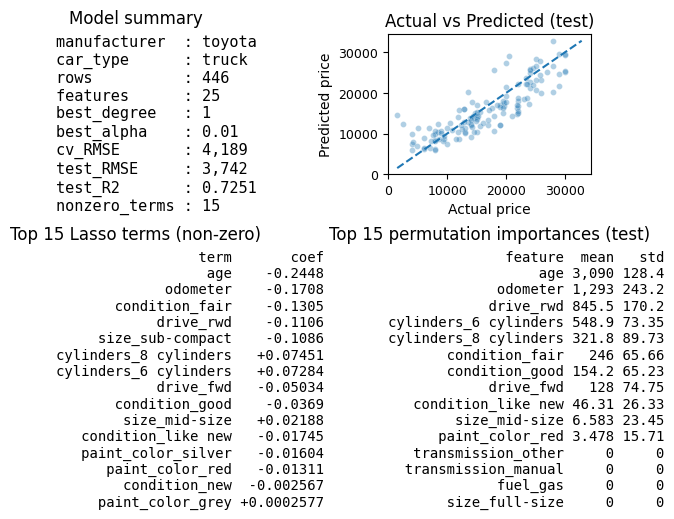

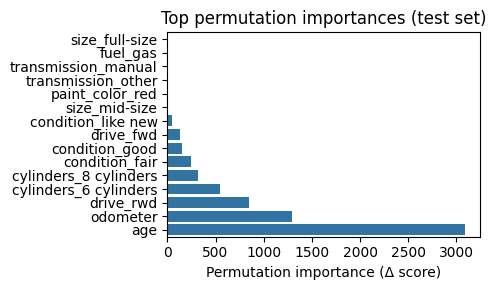

In [28]:
results_toyota_truck = analyse_manufacturer_type(df_raw, manufacturer="toyota", car_type="truck")

,manufacturer,car_type,rows,features,best_degree,best_alpha,cv_RMSE,train_RMSE,test_RMSE,test_R2,nonzero_lasso_terms
0,jeep,SUV,1529,32,1,0.01,"4,729.21","4,524.90","4,914.68",0.5687,23


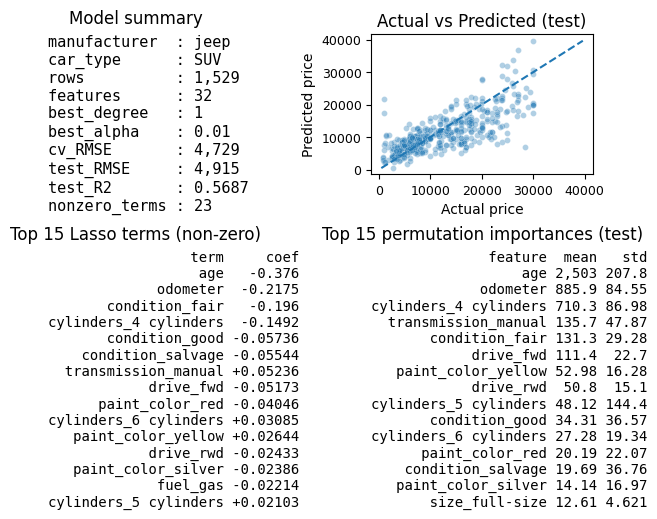

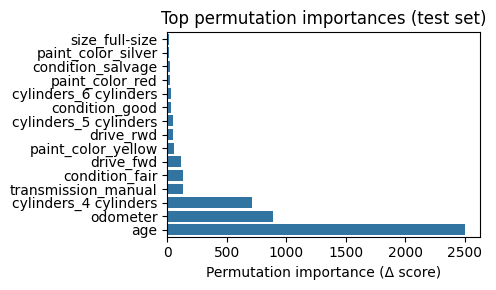

In [29]:
results_jeep_suv = analyse_manufacturer_type(df_raw, manufacturer="jeep", car_type="SUV")

,manufacturer,car_type,rows,features,best_degree,best_alpha,cv_RMSE,train_RMSE,test_RMSE,test_R2,nonzero_lasso_terms
0,saturn,sedan,99,23,1,0.01,"1,697.42","1,177.75","1,740.87",0.0372,21


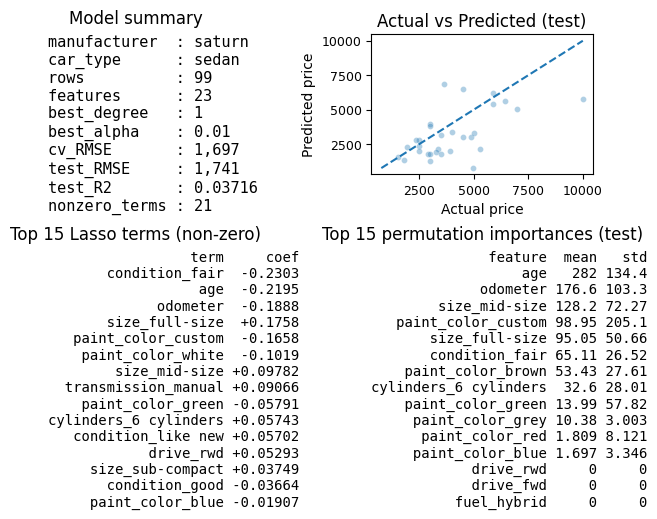

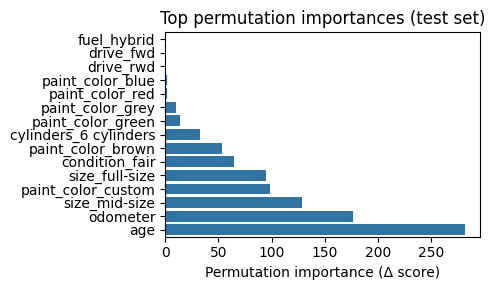

In [30]:
results_saturn_sedan = analyse_manufacturer_type(df_raw, manufacturer="saturn", car_type="sedan")

Okay, we generated a few reports for combinations of manufacturers and car types. Now let's loop over all manufacturers and car types and leave only those that have at least 300 cars, just to have some kind of statistics, and extract the four most important features.

We collect all the most important features and display a plot of the most import features - a plot for aech car tyep and manufacturer on y axis. This will give us a good overview of the most important features for each car type and manufacturer, and also we can see whether there are any common features that are important across different types and manufacturers.

ANALYZING FEATURE COEFFICIENTS BY CAR TYPE (≥200 cars)

✓ ACURA - SUV (n=203, R²=0.8765)

✓ BMW - SUV (n=347, R²=0.7015)

✓ CADILLAC - SUV (n=232, R²=0.5995)

✓ CHEVROLET - SUV (n=1465, R²=0.8091)

✓ DODGE - SUV (n=308, R²=0.6425)

✓ FORD - SUV (n=1781, R²=0.7843)

✓ GMC - SUV (n=711, R²=0.7634)

✓ HONDA - SUV (n=892, R²=0.7736)

✓ HYUNDAI - SUV (n=341, R²=0.7539)

✓ JEEP - SUV (n=1529, R²=0.5687)

✓ KIA - SUV (n=304, R²=0.7815)

✓ LEXUS - SUV (n=328, R²=0.6918)

✓ MERCEDES-BENZ - SUV (n=235, R²=0.5385)

✓ NISSAN - SUV (n=835, R²=0.8615)

✓ SUBARU - SUV (n=386, R²=0.8669)

✓ TOYOTA - SUV (n=1078, R²=0.6169)

✓ CHEVROLET - COUPE (n=229, R²=0.5996)

✓ FORD - COUPE (n=258, R²=0.8578)

✓ HONDA - COUPE (n=347, R²=0.8836)

✓ FORD - HATCHBACK (n=221, R²=0.6509)

✓ TOYOTA - HATCHBACK (n=443, R²=0.8149)

✓ CHRYSLER - MINI-VAN (n=233, R²=0.4495)

✓ DODGE - MINI-VAN (n=276, R²=0.6070)

✓ HONDA - MINI-VAN (n=285, R²=0.5188)

✓ TOYOTA - MINI-VAN (n=231, R²=0.7300)

✓ CHEVROLET - PICKUP (n=745, R²=0

,n_rows,test_R2
car_type,,
wagon,352,0.839829
coupe,834,0.780309
hatchback,664,0.732893
SUV,10975,0.726869
sedan,13045,0.688327
van,759,0.687916
pickup,2894,0.618461
truck,4621,0.611172
mini-van,1025,0.576296



LASSO COEFFICIENTS BY CAR TYPE

Features present in models across car types:
car_type                     SUV     coupe  hatchback  mini-van    pickup  \
feature                                                                     
age                    -0.456725 -0.070993  -0.268198 -0.355202 -0.345596   
condition_fair         -0.121107 -0.199625  -0.118289 -0.163956 -0.158793   
condition_good         -0.047234 -0.061249  -0.051436 -0.135216 -0.110123   
condition_like new     -0.038928 -0.017182   0.000000  0.062085  0.013245   
condition_new           0.005432 -0.022020   0.000000 -0.011779  0.006187   
condition_salvage      -0.076848 -0.114764   0.000000  0.000000 -0.144736   
cylinders_12 cylinders  0.000000  0.000000   0.000000  0.000000  0.000000   
cylinders_3 cylinders  -0.048763  0.000000   0.000000  0.000000  0.000000   
cylinders_4 cylinders  -0.009185 -0.028526   0.000000 -0.028676 -0.068853   
cylinders_5 cylinders   0.015318  0.000000   0.011369  0.000000  0.016042  

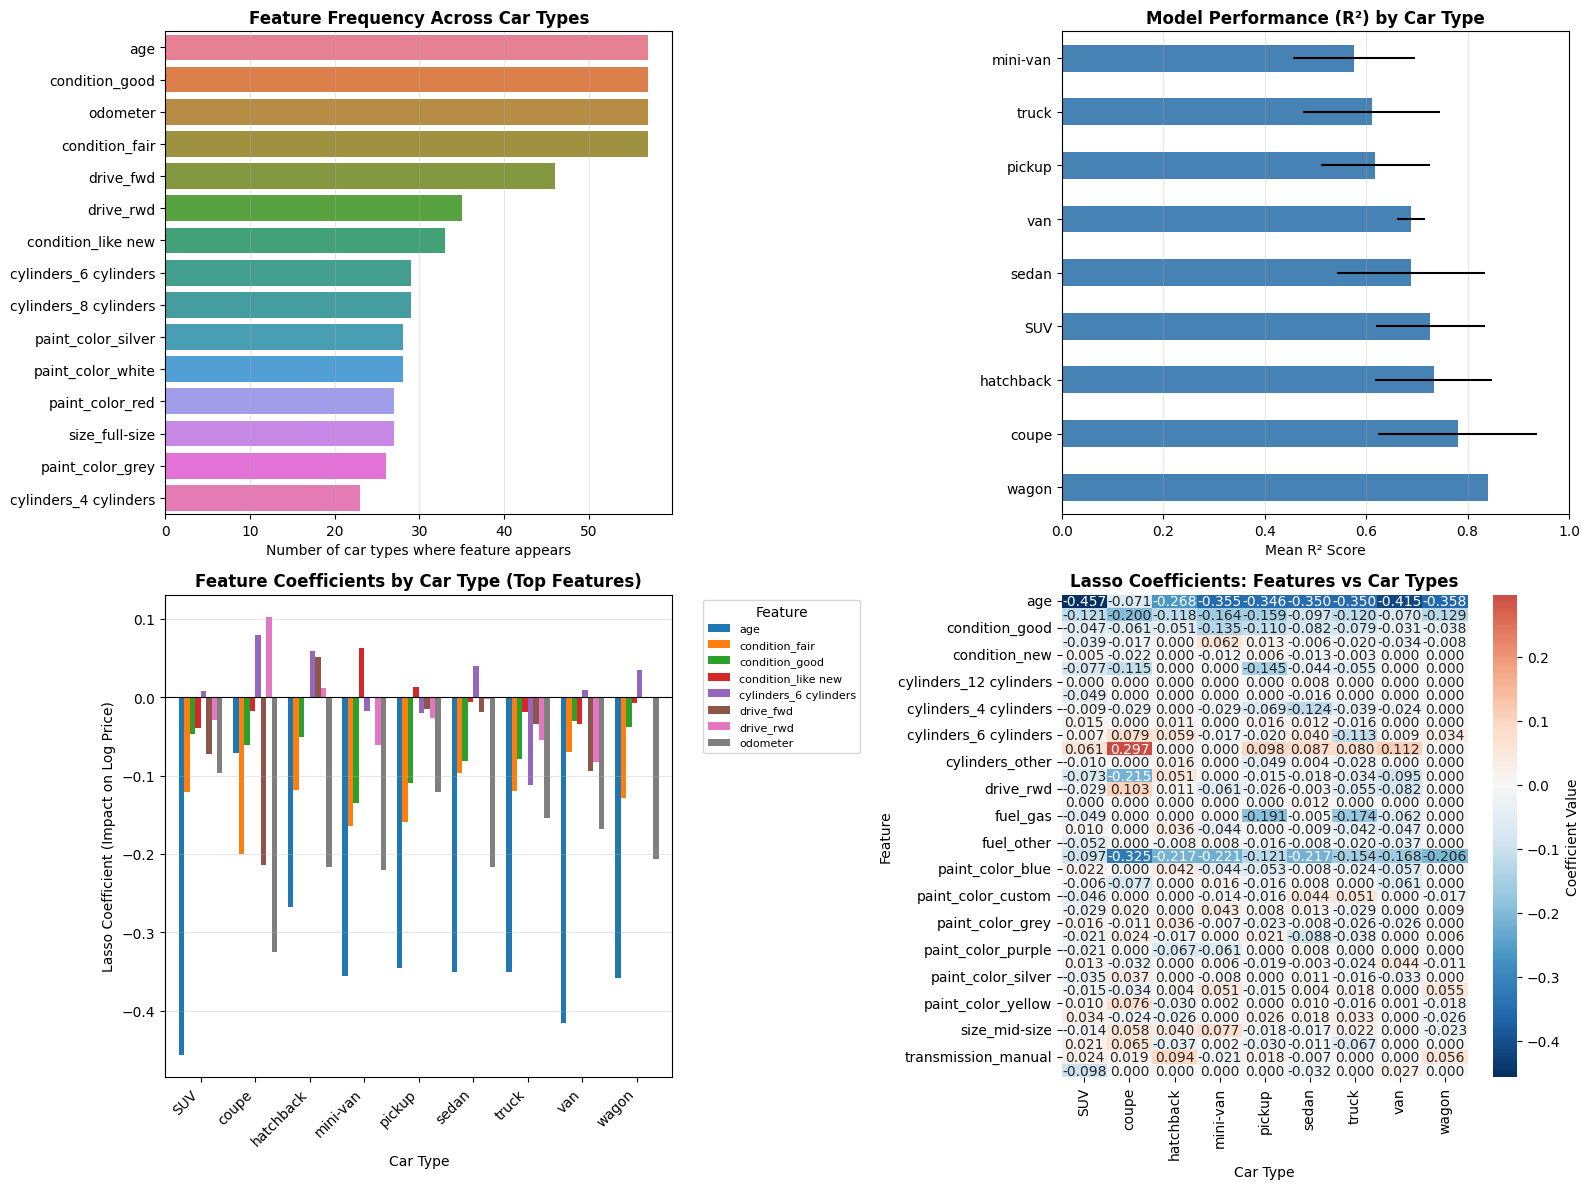


DETAILED COEFFICIENT ANALYSIS BY CAR TYPE

CAR TYPE: SUV
Manufacturers analyzed: 16
Average R²: 0.7269
Total cars: 10975

Top Features and Their Coefficients (averaged across manufacturers):
                       mean_coef  std_coef  min_coef  max_coef  n_models
feature                                                                 
age                      -0.3968    0.0655   -0.5176   -0.3011        16
cylinders_4 cylinders    -0.1564    0.1872   -0.4787   -0.0092         5
odometer                 -0.1560    0.0348   -0.2175   -0.0968        16
condition_fair           -0.1115    0.0328   -0.1960   -0.0741        16
cylinders_8 cylinders     0.0993    0.1603   -0.2612    0.2968        10
fuel_gas                 -0.0801    0.1020   -0.2317   -0.0176         4
condition_new            -0.0642    0.0969   -0.2264    0.0075         5
fuel_other               -0.0524       NaN   -0.0524   -0.0524         1
cylinders_3 cylinders    -0.0488       NaN   -0.0488   -0.0488         1
condi

In [31]:

# Collect results for all car_type combinations with at least 200 cars
# Focus on car_type to show how feature impacts vary across different car types

all_results = []
all_coefficients = []

print("="*80)
print("ANALYZING FEATURE COEFFICIENTS BY CAR TYPE (≥200 cars)")
print("="*80)

# Collect ALL manufacturers for each car_type
for car_type in sorted(df_raw["type"].unique()):
    type_results = []
    type_coefficients = []

    for manufacturer in sorted(df_raw["manufacturer"].unique()):
        try:
            result = analyse_manufacturer_type(
                df_raw,
                manufacturer=manufacturer,
                car_type=car_type,
                show_report=False
            )
            n_rows = result["summary"]["rows"].values[0]

            if n_rows >= 200:
                # Store summary info (excluding RMSE, focusing on R²)
                type_results.append({
                    "manufacturer": manufacturer,
                    "car_type": car_type,
                    "n_rows": n_rows,
                    "test_R2": result["summary"]["test_R2"].values[0],
                })

                # Extract Lasso coefficients (not permutation importance!)
                # coef_top already has the non-zero terms sorted by absolute value
                coef_df = result["coef_top"]
                for idx, row in coef_df.iterrows():
                    type_coefficients.append({
                        "manufacturer": manufacturer,
                        "car_type": car_type,
                        "feature": row["term"],
                        "coefficient": row["coef"],
                    })

                print(f"\n✓ {manufacturer.upper()} - {car_type.upper()} (n={n_rows}, R²={result['summary']['test_R2'].values[0]:.4f})")

        except ValueError as e:
            pass

    all_results.extend(type_results)
    all_coefficients.extend(type_coefficients)

# Create summary DataFrame for results
results_summary_df = pd.DataFrame(all_results)
print("\n" + "="*80)
print("SUMMARY BY CAR TYPE")
print("="*80)
if len(results_summary_df) > 0:
    summary_by_type = results_summary_df.groupby("car_type").agg({
        "n_rows": "sum",
        "test_R2": "mean"
    }).sort_values("test_R2", ascending=False)
    display(summary_by_type)

# Create DataFrame with all coefficients
all_coef_df = pd.DataFrame(all_coefficients)

print("\n" + "="*80)
print("LASSO COEFFICIENTS BY CAR TYPE")
print("="*80)

# Extract key numeric features from polynomial terms
# For polynomial features, the original features appear directly (degree 1)
# Focus on first-order terms (not polynomial interactions)

# Identify features that appear multiple times across car types
feature_car_type_coef = all_coef_df.pivot_table(
    values="coefficient",
    index="feature",
    columns="car_type",
    aggfunc="first"  # Take first occurrence
).fillna(0)

print("\nFeatures present in models across car types:")
print(feature_car_type_coef)

# ====== VISUALIZATIONS ======

# 1. Feature Frequency Plot (good as you mentioned)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

ax1 = axes[0, 0]
feature_frequency = all_coef_df.groupby("feature").size().sort_values(ascending=False).head(15)
sns.barplot(y=feature_frequency.index, x=feature_frequency.values, orient="h", ax=ax1, hue=feature_frequency.index, legend=False)
ax1.set_xlabel("Number of car types where feature appears")
ax1.set_ylabel("")
ax1.set_title("Feature Frequency Across Car Types", fontsize=12, fontweight="bold")
ax1.grid(axis="x", alpha=0.3)

# 2. Model Performance (R² by car type)
ax2 = axes[0, 1]
if len(results_summary_df) > 0:
    r2_by_type = results_summary_df.groupby("car_type")["test_R2"].agg(["mean", "std"]).sort_values("mean", ascending=False)
    r2_by_type["mean"].plot(kind="barh", ax=ax2, color="steelblue", xerr=r2_by_type["std"])
    ax2.set_xlabel("Mean R² Score")
    ax2.set_ylabel("")
    ax2.set_title("Model Performance (R²) by Car Type", fontsize=12, fontweight="bold")
    ax2.grid(axis="x", alpha=0.3)
    ax2.set_xlim([0, 1])

# 3. Coefficient magnitude by car type (for top features)
ax3 = axes[1, 0]
top_features_by_freq = feature_frequency.head(8).index.tolist()
coef_subset = all_coef_df[all_coef_df["feature"].isin(top_features_by_freq)]

# Prepare data for grouped bar plot
coef_pivot = coef_subset.pivot_table(
    values="coefficient",
    index="feature",
    columns="car_type",
    aggfunc="first"
).fillna(0)

coef_pivot.T.plot(kind="bar", ax=ax3, width=0.8)
ax3.set_title("Feature Coefficients by Car Type (Top Features)", fontsize=12, fontweight="bold")
ax3.set_xlabel("Car Type")
ax3.set_ylabel("Lasso Coefficient (Impact on Log Price)")
ax3.legend(title="Feature", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
ax3.grid(axis="y", alpha=0.3)
ax3.axhline(y=0, color="black", linestyle="-", linewidth=0.8)
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45, ha="right")

# 4. Detailed heatmap of coefficients
ax4 = axes[1, 1]
# Show all features that appear in any model
if len(feature_car_type_coef) > 0:
    sns.heatmap(
        feature_car_type_coef,
        annot=True,
        fmt=".3f",
        cmap="RdBu_r",
        center=0,
        ax=ax4,
        cbar_kws={"label": "Coefficient Value"}
    )
    ax4.set_title("Lasso Coefficients: Features vs Car Types", fontsize=12, fontweight="bold")
    ax4.set_xlabel("Car Type")
    ax4.set_ylabel("Feature")

plt.tight_layout()
plt.show()

# ====== DETAILED ANALYSIS BY CAR TYPE ======
print("\n" + "="*80)
print("DETAILED COEFFICIENT ANALYSIS BY CAR TYPE")
print("="*80)

for car_type in sorted(results_summary_df["car_type"].unique()):
    print(f"\n{'='*60}")
    print(f"CAR TYPE: {car_type.upper()}")
    print(f"{'='*60}")

    # Get all models for this car type
    type_data = results_summary_df[results_summary_df["car_type"] == car_type]
    print(f"Manufacturers analyzed: {len(type_data)}")
    print(f"Average R²: {type_data['test_R2'].mean():.4f}")
    print(f"Total cars: {type_data['n_rows'].sum()}")

    # Get coefficients for this car type
    type_coef = all_coef_df[all_coef_df["car_type"] == car_type].copy()
    type_coef_summary = type_coef.groupby("feature").agg({
        "coefficient": ["mean", "std", "min", "max", "count"]
    }).round(4)
    type_coef_summary.columns = ["mean_coef", "std_coef", "min_coef", "max_coef", "n_models"]
    type_coef_summary = type_coef_summary.sort_values("mean_coef", key=abs, ascending=False)

    print("\nTop Features and Their Coefficients (averaged across manufacturers):")
    print(type_coef_summary.head(10).to_string())

# ====== KEY INSIGHTS ======
print("\n" + "="*80)
print("KEY INSIGHTS: FEATURE IMPACT VARIATION ACROSS CAR TYPES")
print("="*80)

# For each feature, show how its coefficient varies across car types
feature_list = all_coef_df["feature"].unique()
for feature in sorted(feature_list)[:10]:  # Show top 10 features
    feature_data = all_coef_df[all_coef_df["feature"] == feature]
    coef_by_type = feature_data.groupby("car_type")["coefficient"].agg(["mean", "std", "count"])

    if len(coef_by_type) > 1:  # Only if appears in multiple car types
        print(f"\n{feature}:")
        print(f"  Varies by car type: ", end="")
        coef_values = coef_by_type["mean"].values
        if len(coef_values) > 0:
            min_coef = coef_values.min()
            max_coef = coef_values.max()
            print(f"from {min_coef:+.4f} to {max_coef:+.4f} (range: {max_coef - min_coef:.4f})")
            for car_type, row in coef_by_type.iterrows():
                print(f"    {car_type:15s}: {row['mean']:+.4f} (n={int(row['count'])} manufacturers)")
        else:
            print("No data")



### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.